# EDA — What Drives House Prices in Ames?

**Module 2 · Business Analytics group project**

Input: `data/synthetic/ames_extended.csv` (1,472 listings, Jan 2006 – Jul 2010 —
Kaggle Ames base + synthetic contextual fields, see `DATA_DICTIONARY.md`).
This notebook answers three business questions:

1. **What drives price?** (so the platform knows which listing attributes matter)
2. **How does the market move over time?** (the crisis-era trend our model must survive)
3. **Which variables are redundant?** (multicollinearity that would destabilize linear models)

Figures are saved to `reports/figures/` for the final report.
NOTE: this notebook runs on the *raw extended* data (pre-cleaning) — data-quality
issues found here feed Module 3.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import DATA_SYNTHETIC_DIR, ROOT_DIR

FIG_DIR = ROOT_DIR / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", palette="deep")

df = pd.read_csv(DATA_SYNTHETIC_DIR / "ames_extended.csv", parse_dates=["listing_date"])
print(f"{df.shape[0]} listings x {df.shape[1]} columns, "
      f"{df.listing_date.min():%Y-%m} to {df.listing_date.max():%Y-%m}")

1472 listings x 92 columns, 2006-01 to 2010-07


## 1. The target: sale price is right-skewed → model on log scale

Median $162,900 vs mean $181,407, with a long right tail up to $781k. Skewness
1.93 falls to 0.12 after log transform — an early, load-bearing decision for
Module 4: errors on expensive homes would otherwise dominate training.

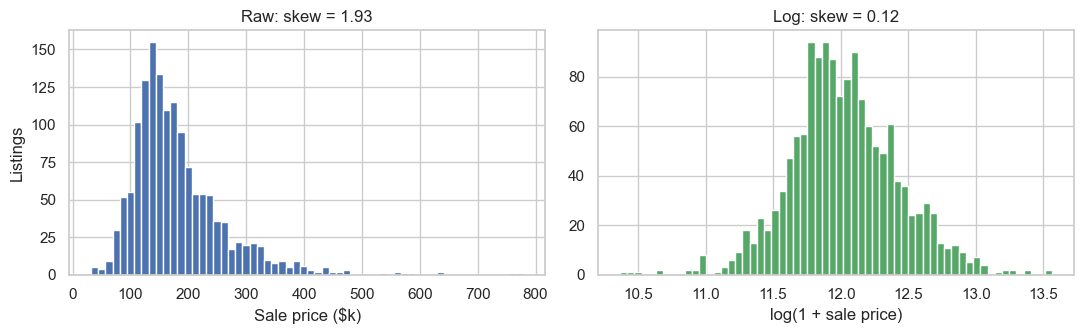

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(df.sale_price / 1000, bins=60, color="#4C72B0")
axes[0].set(xlabel="Sale price ($k)", ylabel="Listings", title=f"Raw: skew = {df.sale_price.skew():.2f}")
axes[1].hist(np.log1p(df.sale_price), bins=60, color="#55A868")
axes[1].set(xlabel="log(1 + sale price)", title=f"Log: skew = {np.log1p(df.sale_price).skew():.2f}")
fig.tight_layout(); fig.savefig(FIG_DIR / "01_target_distribution.png", dpi=120)
plt.show()

## 2. Market over time: boom → crisis → early rebound

Monthly median price (3-month smoothed) tracks the synthetic market index:
up ~5% to mid-2007, down ~10% through 2009, rebounding in 2010. Interest rates
fall from 6.6% to 4.7% over the window. Days-on-market lengthens in the cold
2008–09 market (median 38 days vs 32.5 in 2006).

**Monitoring implication:** the 2010 rebound sits entirely in the held-out
stream — a model trained on 2006–09 will systematically under-predict there.

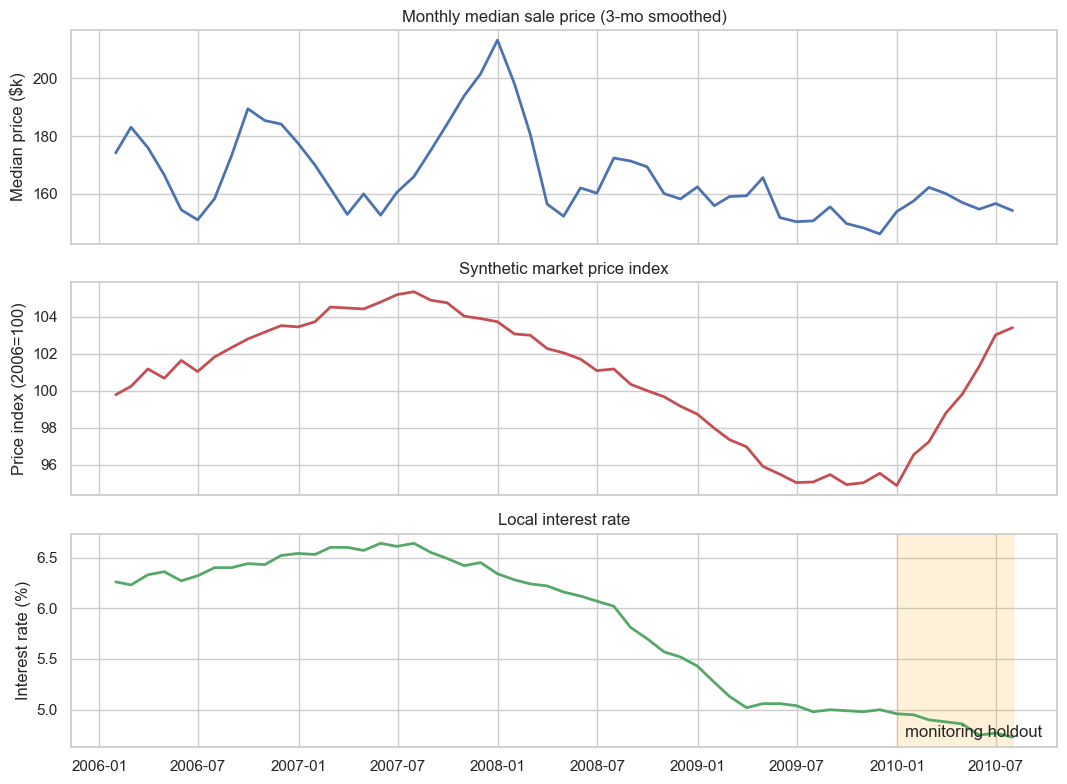

Median days-on-market by year:
listing_date
2006    32.5
2007    34.0
2008    38.0
2009    37.0
2010    30.0
Name: days_on_market, dtype: float64


In [3]:
monthly = df.set_index("listing_date").resample("ME").agg(
    med_price=("sale_price", "median"), rate=("local_interest_rate_pct", "mean"),
    price_index=("market_price_index", "mean"))
dom = (df[df.days_on_market != 999]  # exclude sentinel dirt (see Module 3)
       .set_index("listing_date").resample("QE").days_on_market.median())

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
axes[0].plot(monthly.index, monthly.med_price.rolling(3, min_periods=1).mean() / 1000, lw=2)
axes[0].set(ylabel="Median price ($k)", title="Monthly median sale price (3-mo smoothed)")
axes[1].plot(monthly.index, monthly.price_index, lw=2, color="#C44E52")
axes[1].set(ylabel="Price index (2006=100)", title="Synthetic market price index")
axes[2].plot(monthly.index, monthly.rate, lw=2, color="#55A868")
axes[2].set(ylabel="Interest rate (%)", title="Local interest rate")
axes[2].axvspan(pd.Timestamp("2010-01-01"), monthly.index.max(), alpha=0.15, color="orange")
axes[2].annotate("monitoring holdout", (pd.Timestamp("2010-01-15"), axes[2].get_ylim()[0] + 0.1))
fig.tight_layout(); fig.savefig(FIG_DIR / "02_market_over_time.png", dpi=120)
plt.show()
print("Median days-on-market by year:")
print(df[df.days_on_market != 999].groupby(df.listing_date.dt.year).days_on_market.median())

## 3. Top price drivers

Overall quality (r = 0.79) and living area (r = 0.71) dominate — the classic
Ames result. Our synthetic amenity fields behave as designed: school distance
r = −0.60 (closer = pricier), hospital −0.58, while transit distance is
deliberately near-zero (bus lines don't follow wealth).

`renovation_cost_usd` (r = 0.69) is high but partly *derivative* — it was
generated from area × quality, so it echoes those drivers rather than adding
independent signal. Flagged for the multicollinearity check (§6).

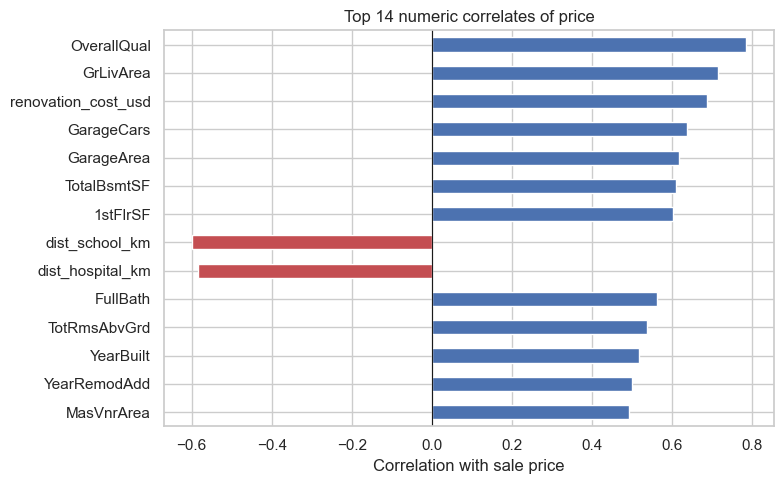

In [4]:
num_cols = df.select_dtypes("number").drop(columns=["Id", "sale_price_kaggle"])
corr = num_cols.corr(numeric_only=True)["sale_price"].drop("sale_price")
top = corr.reindex(corr.abs().sort_values(ascending=False).index).head(14)

fig, ax = plt.subplots(figsize=(8, 5))
top[::-1].plot.barh(ax=ax, color=np.where(top[::-1] > 0, "#4C72B0", "#C44E52"))
ax.set(xlabel="Correlation with sale price", title="Top 14 numeric correlates of price")
ax.axvline(0, color="k", lw=0.8)
fig.tight_layout(); fig.savefig(FIG_DIR / "03_top_price_drivers.png", dpi=120)
plt.show()

## 4. Quality, size, and the two notorious outliers

Median price nearly quadruples from quality 3 ($85k) to quality 9 ($346k).
The price–area scatter shows two homes >4,000 sq ft sold under $300k
(Ids 524, 1299) — known partial/abnormal sales in the Ames data. They sit far
off the trend and will be removed in Module 3 with justification.

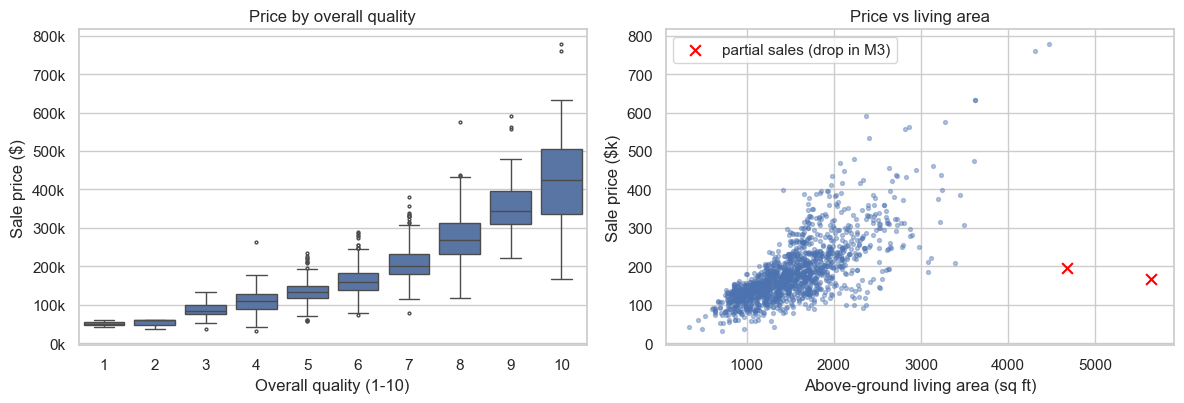

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.boxplot(data=df, x="OverallQual", y="sale_price", ax=axes[0], fliersize=2)
axes[0].set(title="Price by overall quality", xlabel="Overall quality (1-10)", ylabel="Sale price ($)")
axes[0].yaxis.set_major_formatter(lambda v, _: f"{v/1000:.0f}k")

out = (df.GrLivArea > 4000) & (df.sale_price < 300_000)
axes[1].scatter(df.GrLivArea[~out], df.sale_price[~out] / 1000, s=8, alpha=0.4)
axes[1].scatter(df.GrLivArea[out], df.sale_price[out] / 1000, s=60, color="red", marker="x", label="partial sales (drop in M3)")
axes[1].set(title="Price vs living area", xlabel="Above-ground living area (sq ft)", ylabel="Sale price ($k)")
axes[1].legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "04_quality_area_outliers.png", dpi=120)
plt.show()

## 5. Location: neighborhood is a 3.5× price lever; amenities explain much of it

Median prices range from $90k (MeadowV) to $313k (NridgHt) — a 3.5× spread on
physically comparable homes. The amenity panel shows *why* location carries
this premium in our data: price falls steadily with school distance, while
transit distance is flat — matching the generation assumptions and giving the
platform an actionable story ("proximity to schools is priced in; bus access
is not").

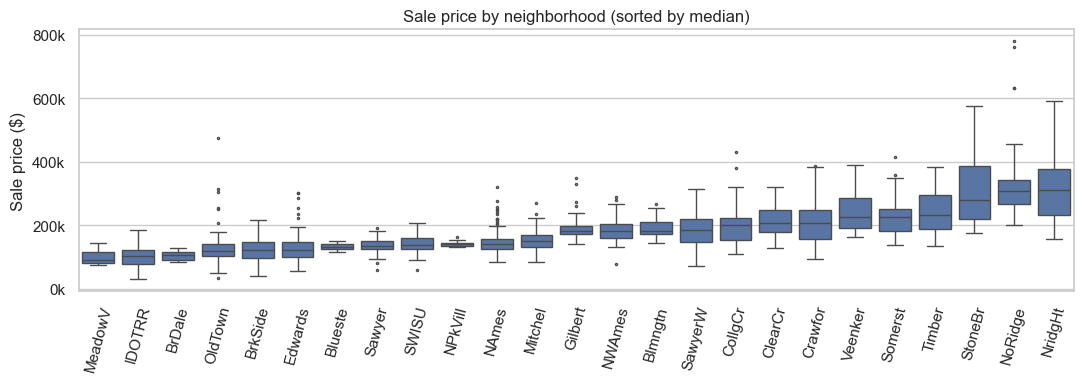

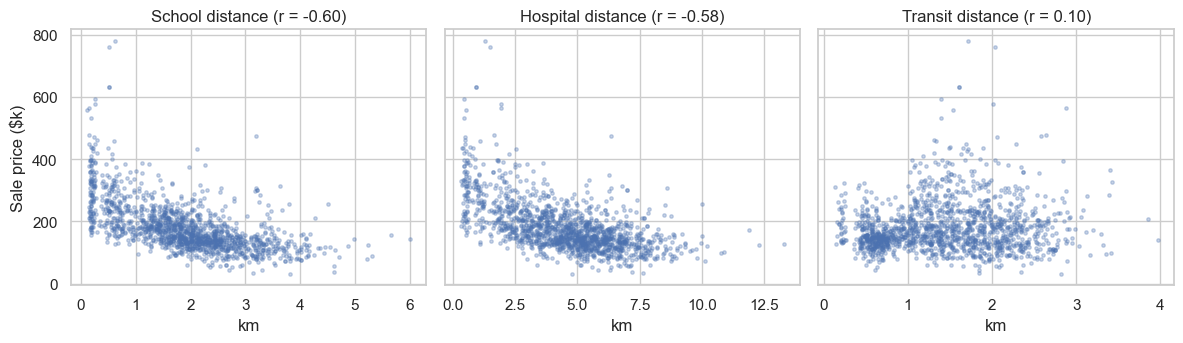

In [6]:
order = df.groupby("Neighborhood").sale_price.median().sort_values().index
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="Neighborhood", y="sale_price", order=order, ax=ax, fliersize=1.5)
ax.tick_params(axis="x", rotation=75); ax.yaxis.set_major_formatter(lambda v, _: f"{v/1000:.0f}k")
ax.set(title="Sale price by neighborhood (sorted by median)", ylabel="Sale price ($)", xlabel="")
fig.tight_layout(); fig.savefig(FIG_DIR / "05_neighborhood_prices.png", dpi=120)
plt.show()

ok = df.dist_transit_km < 100  # exclude meter-entry errors (fixed in M3)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, col, label in zip(axes, ["dist_school_km", "dist_hospital_km", "dist_transit_km"],
                          ["School", "Hospital", "Transit"]):
    sub = df[ok] if col == "dist_transit_km" else df
    ax.scatter(sub[col], sub.sale_price / 1000, s=6, alpha=0.3)
    r = sub[col].corr(sub.sale_price)
    ax.set(title=f"{label} distance (r = {r:.2f})", xlabel="km")
axes[0].set_ylabel("Sale price ($k)")
fig.tight_layout(); fig.savefig(FIG_DIR / "06_amenity_distances.png", dpi=120)
plt.show()

## 6. Multicollinearity: several variable pairs say the same thing

Four pairs exceed r = 0.8: garage cars/area (0.88), rooms/living area (0.83),
1st-floor/basement size (0.82), year built/garage year (0.83). Plus
renovation cost echoes area × quality by construction. Linear models in
Module 4 will use a pruned feature set (formal VIF check happens there);
tree models are robust to this but we document it regardless.

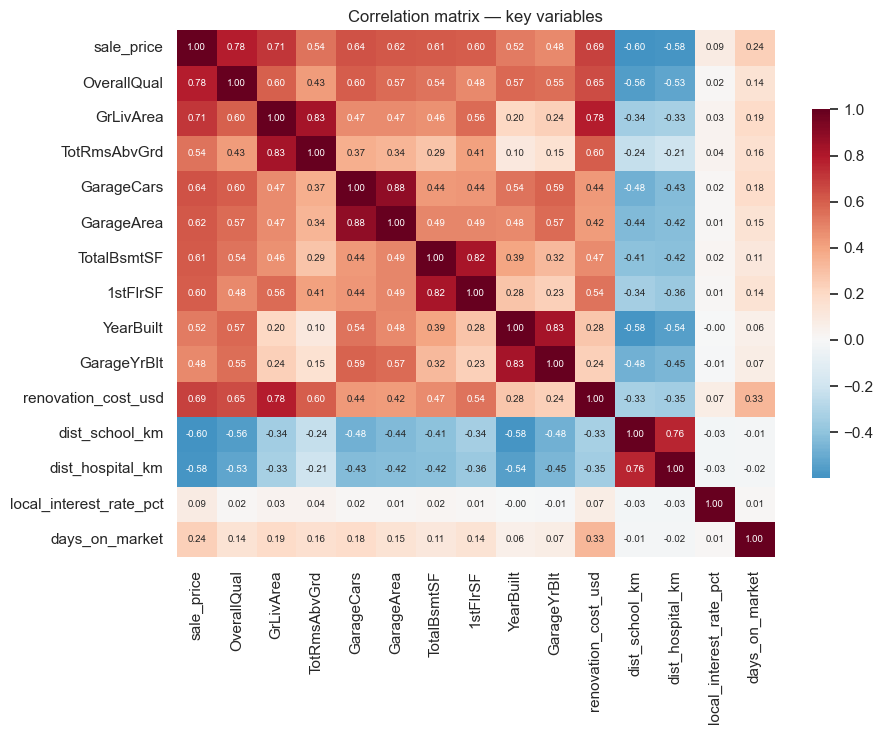

In [7]:
key = ["sale_price", "OverallQual", "GrLivArea", "TotRmsAbvGrd", "GarageCars",
       "GarageArea", "TotalBsmtSF", "1stFlrSF", "YearBuilt", "GarageYrBlt",
       "renovation_cost_usd", "dist_school_km", "dist_hospital_km",
       "local_interest_rate_pct", "days_on_market"]
cm = df[key].corr()
fig, ax = plt.subplots(figsize=(9.5, 7.5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.7})
ax.set_title("Correlation matrix — key variables")
fig.tight_layout(); fig.savefig(FIG_DIR / "07_correlation_heatmap.png", dpi=120)
plt.show()

## 7. Data-quality problems spotted (handoff to Module 3)

The raw extended table carries visible dirt — all in synthetic fields, all
pre-2010 (see `DATA_DICTIONARY.md` for injection rates):

| Issue | Evidence |
|---|---|
| Missing school distances | 26 blank rows |
| Messy renovated labels | 8 variants: Yes/Y/yes/YES/No/N/no/NO |
| Days-on-market sentinel | 5 rows at exactly 999 |
| Transit distance unit errors | 4 rows > 100 km (metres, not km) |
| Duplicate listings | 12 homes appear twice with different listing ids |
| Kaggle-side gaps | PoolQC/MiscFeature/Alley/Fence mostly NA — *means "feature absent", not missing* |
| Partial-sale outliers | Ids 524, 1299 (huge area, low price) |

## Key take-aways

1. **Quality and size dominate price**; neighborhood adds a 3.5× multiplier largely explained by amenity access (schools).
2. **Model on log price** (skew 1.93 → 0.12).
3. **The market moved a lot** over 2006–10 — a fixed model will age; monitoring is not optional.
4. **Prune redundant variables** for linear models; drop 2 documented outliers.
5. Transit access is *not* priced — a testable, falsifiable claim our generator made on purpose.

In [8]:
summary = {
    "n_listings": len(df),
    "missing_dist_school": int(df.dist_school_km.isna().sum()),
    "messy_labels": sorted(df.renovated.unique().tolist()),
    "dom_999": int((df.days_on_market == 999).sum()),
    "transit_meter_errors": int((df.dist_transit_km > 100).sum()),
    "duplicate_ids": int(df.Id.duplicated().sum()),
}
summary

{'n_listings': 1472,
 'missing_dist_school': 26,
 'messy_labels': ['N', 'NO', 'No', 'Y', 'YES', 'Yes', 'no', 'yes'],
 'dom_999': 5,
 'transit_meter_errors': 4,
 'duplicate_ids': 12}